# 01 - PTB-XL exploratory data analysis

PTB-XL is the only source in this project with diagnostic labels, and its folds 9
and 10 are the validation and test sets for every reported result. If something
is wrong here, it is wrong everywhere, so this notebook goes first and in the most
detail.

Everything below is computed from the **raw PTB-XL 1.0.3 release**
(`data/raw/ptb-xl/1.0.3/`): the metadata CSVs and the original WFDB waveform files.
The project's own manifests and arrays are only read to compare against.
The analysis code lives in `eda/` as plain Python; this notebook only calls it and
explains what comes out.

**How to read it.** Each section starts with the question, shows the evidence, and
ends with a short *Finding* that explains what it means and what we check next.
The main conclusions are collected at the end.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eda.processed import compare_cache_100, compare_pool, compare_union, join_example
from eda.ptbxl import load_statements, read_signal
from eda.ptbxl_labels import (
    labeled_metadata,
    metadata_baselines,
    patient_repeats,
    positive_rates,
    reproduction_mismatches,
    split_integrity,
    unlabeled_composition,
)
from eda.ptbxl_signals import annotation_agreement, lead_features, low_rate_consistency, ptbxl_summary
from eda.signals import LEADS, plot_ecg, problem_counts

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

meta = labeled_metadata()
statements = load_statements()

## 1. The data at a glance

First, the basic shape: how many recordings, how many patients, and how the
official folds are sized. PTB-XL ships ten stratified folds; the project uses
folds 1-8 for training, 9 for validation and 10 for test.

In [3]:
overview = pd.Series({
    "recordings": len(meta),
    "patients": meta["patient_id"].nunique(),
    "metadata columns": meta.shape[1],
    "first recording": meta["recording_date"].min().date(),
    "last recording": meta["recording_date"].max().date(),
})
display(overview.to_frame("value"))
display(meta.groupby("strat_fold").agg(records=("patient_id", "size"),
                                       patients=("patient_id", "nunique"),
                                       human_validated=("validated_by_human", "mean")).T.round(2))

,value
recordings,21799
patients,18869
metadata columns,32
first recording,1984-11-09
last recording,2001-06-11


strat_fold,1,2,3,4,5,6,7,8,9,10
records,2175.00,2181.00,2192.00,2174.00,2174.00,2173.00,2176.00,2173.00,2183.0,2198.0
patients,1878.00,1849.00,1887.00,1883.00,1890.00,1884.00,1871.00,1881.00,1942.0,1904.0
human_validated,0.67,0.66,0.67,0.68,0.68,0.64,0.68,0.68,1.0,1.0


**Finding.** 21,799 ten-second recordings from 18,869 patients, collected between
1984 and 2001. The folds are balanced in size (about 2,180 records each). Folds 9
and 10 are 100% human-validated, against roughly two thirds for the other folds.
That is the reason PTB-XL recommends them for evaluation, and the project follows
this correctly.

Because patients can have several recordings, we check patient-level splits later.
First, what is missing.

## 2. Missing values

Missing values matter for two reasons: they limit which metadata can be used as
covariates, and in PTB-XL several columns use "missing" to mean "not annotated"
rather than "unknown".

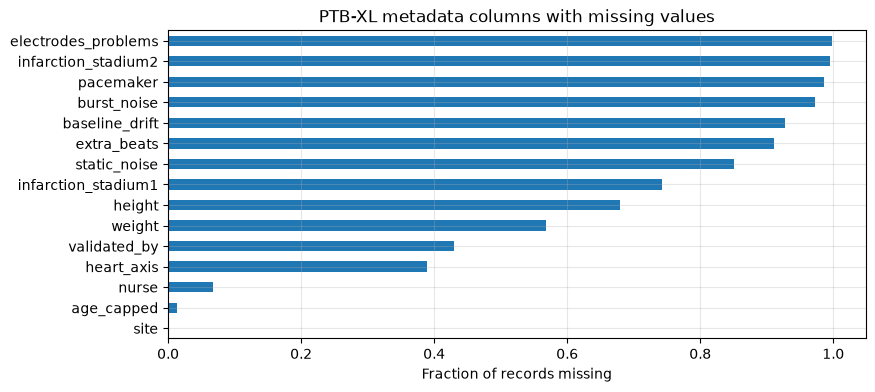

,missing fraction
electrodes_problems,0.999
infarction_stadium2,0.995
pacemaker,0.987
burst_noise,0.972
baseline_drift,0.927
extra_beats,0.911
static_noise,0.850
infarction_stadium1,0.743
height,0.680
weight,0.568


In [4]:
missing = meta.drop(columns=["scp_codes"]).isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(9, 4))
missing.plot.barh(ax=ax, color="tab:blue")
ax.set(xlabel="Fraction of records missing", title="PTB-XL metadata columns with missing values")
ax.invert_yaxis()
plt.show()
display(missing.round(3).to_frame("missing fraction"))

In [5]:
placeholder_age = (meta["age"] == 300).sum()
implausible = pd.Series({
    "age == 300 (placeholder for > 89 years)": placeholder_age,
    "height < 100 cm": (meta["height"] < 100).sum(),
    "weight < 30 kg": (meta["weight"] < 30).sum(),
    "sex coded 0 (male)": (meta["sex"] == 0).sum(),
    "sex coded 1 (female)": (meta["sex"] == 1).sum(),
})
display(implausible.to_frame("records"))

,records
age == 300 (placeholder for > 89 years),293
height < 100 cm,13
weight < 30 kg,12
sex coded 0 (male),11354
sex coded 1 (female),10445


**Finding.** The waveforms and the core identifiers (patient, fold, SCP codes, age,
sex) are complete. The gaps are elsewhere:

- The noise columns (`baseline_drift`, `static_noise`, `burst_noise`,
  `electrodes_problems`) are empty in 85-99% of rows. Empty means "the annotator
  noted nothing", not "unknown". Section 7 checks whether these annotations agree
  with what we measure in the signals.
- Height (68% missing) and weight (57% missing) are too sparse to use as covariates.
- Age is always present, but 293 records carry the value 300. This is PTB-XL's
  privacy placeholder for patients older than 89, not a real age. Any analysis that
  treats age as a number must replace it (we use `age_capped`, where it is NaN).

So the usable metadata covariates are age, sex, recording device, site and date.
The next section looks at how they are distributed.

## 3. Who is in the dataset

Distributions of the usable covariates. We look for imbalance and for anything
that differs between the training folds and the evaluation folds.

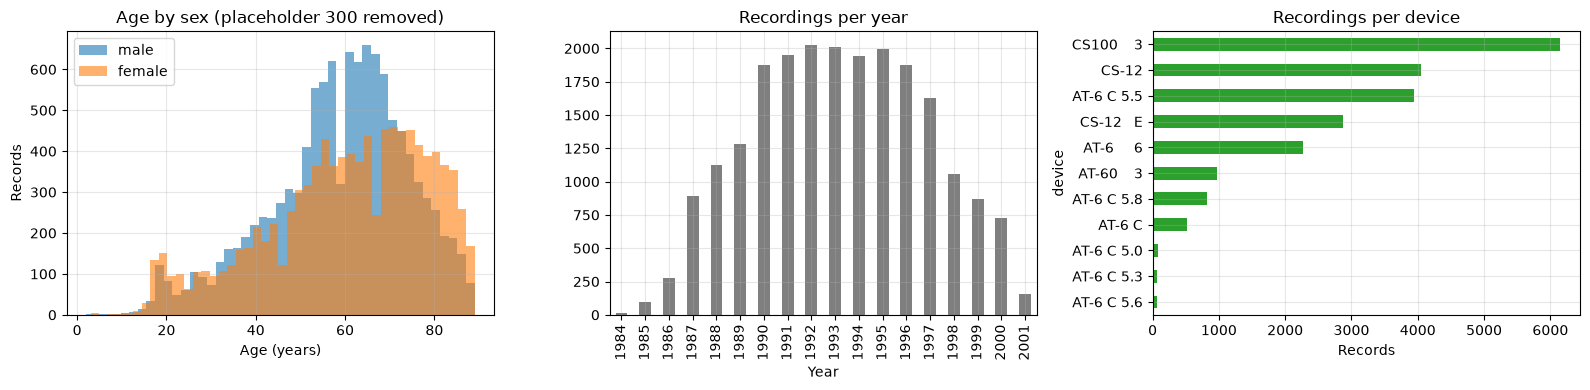

,count,mean,std,min,25%,50%,75%,max
age (years),21506.0,59.5,16.8,2.0,50.0,61.0,72.0,89.0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for sex, name in ((0, "male"), (1, "female")):
    axes[0].hist(meta.loc[meta["sex"] == sex, "age_capped"].dropna(), bins=45, alpha=0.6, label=name)
axes[0].set(title="Age by sex (placeholder 300 removed)", xlabel="Age (years)", ylabel="Records")
axes[0].legend()
meta["recording_date"].dt.year.value_counts().sort_index().plot.bar(ax=axes[1], color="tab:gray")
axes[1].set(title="Recordings per year", xlabel="Year")
meta["device"].value_counts().plot.barh(ax=axes[2], color="tab:green")
axes[2].set(title="Recordings per device", xlabel="Records")
axes[2].invert_yaxis()
plt.tight_layout()
plt.show()
display(meta["age_capped"].describe().round(1).to_frame("age (years)").T)

In [7]:
device_by_split = pd.crosstab(meta["device"], meta["split"], normalize="columns")
device_by_split = device_by_split[["train", "validation", "test"]]
display(device_by_split.round(3).style.background_gradient(axis=None, cmap="Blues").format("{:.1%}"))

split,train,validation,test
device,,,
AT-6 6,10.4%,10.2%,10.9%
AT-6 C,1.7%,5.5%,4.5%
AT-6 C 5.0,0.3%,0.6%,0.6%
AT-6 C 5.3,0.3%,0.5%,0.3%
AT-6 C 5.5,18.2%,18.2%,17.5%
AT-6 C 5.6,0.3%,0.1%,0.3%
AT-6 C 5.8,3.9%,3.4%,3.3%
AT-60 3,3.5%,8.3%,7.9%
CS-12,15.5%,29.5%,32.0%


**Finding.** The population is older (median 61 years once the placeholder is removed) and slightly male-dominated
(52%). Age is broad enough that age-stratified evaluation is possible.

The device table is the important one. Device `CS100 3` makes up **35% of the
training folds but only about 3% of validation and test**. `CS-12` doubles its share
from 16% in training to about 30% in evaluation. The evaluation folds therefore do
not look like the training folds in terms of acquisition hardware. This is a
property of PTB-XL's fold construction (the evaluation folds are the
human-validated recordings), not a bug in the project. It becomes important if
the devices differ in their signals or their label rates, which we test in
sections 6 and 8.

## 4. Diagnostic statements

Each record has a dictionary of SCP-ECG statements with a likelihood (0-100).
Statements are of three kinds: *diagnostic* (grouped into five superclasses:
NORM, MI, STTC, CD, HYP), *form* and *rhythm*.

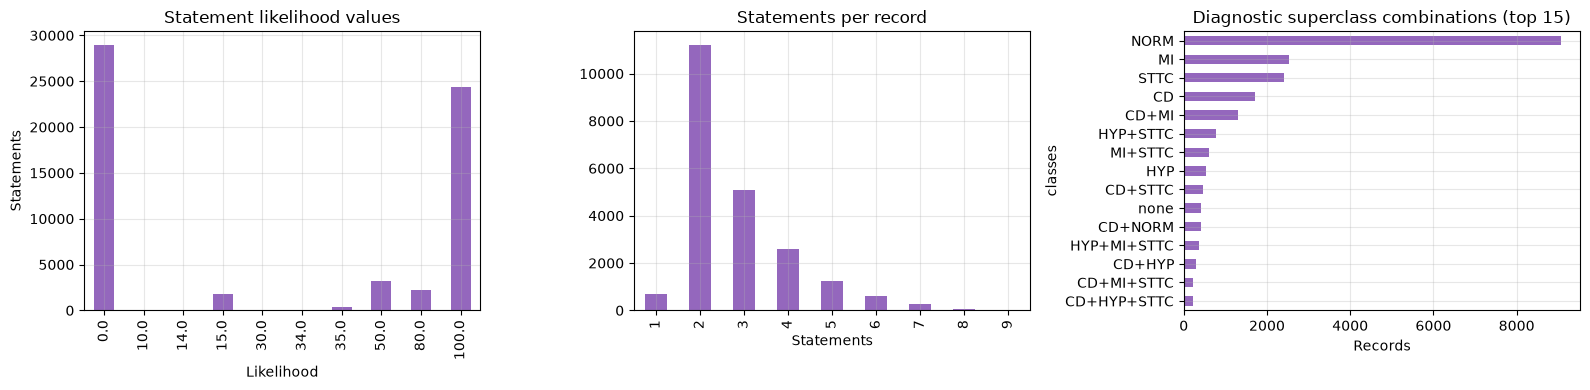

In [8]:
likelihoods = pd.Series([value for codes in meta["scp_codes"] for value in codes.values()])
codes_per_record = meta["scp_codes"].apply(len)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
likelihoods.value_counts().sort_index().plot.bar(ax=axes[0], color="tab:purple")
axes[0].set(title="Statement likelihood values", xlabel="Likelihood", ylabel="Statements")
codes_per_record.value_counts().sort_index().plot.bar(ax=axes[1], color="tab:purple")
axes[1].set(title="Statements per record", xlabel="Statements")
meta["classes"].value_counts().head(15).plot.barh(ax=axes[2], color="tab:purple")
axes[2].set(title="Diagnostic superclass combinations (top 15)", xlabel="Records")
axes[2].invert_yaxis()
plt.tight_layout()
plt.show()

**Finding.** Most likelihoods are either 100 or 0. In PTB-XL, 0 means
"likelihood not specified", not "absent", so a listed code with likelihood 0 is
still a statement about the record (the project code treats it as present, which
matches the dataset's documentation). Records have a median of 2 statements, and
the superclasses overlap heavily: MI together with CD, HYP together with STTC, and
so on. 411 records have **no diagnostic statement at all**. They only carry rhythm
or form codes (pacemaker, atrial fibrillation, flutter...).

With that structure in mind, we can now judge the project's binary label.

## 5. The project's binary label

The project turns the statements into a single binary target
(`scripts/data/prepare_ptbxl.py`):

- **negative (0)**: the record's codes are only `NORM`, or `NORM` and `SR` (sinus rhythm);
- **positive (1)**: no `NORM`, and at least one diagnostic code from MI, STTC, CD or HYP;
- **unlabeled**: everything else. These records stay in self-supervised training
  but are removed from supervised training *and from validation and test*.

We re-implemented the rule independently (`eda/ptbxl.py`) and compare it with every
manifest the project wrote.

In [9]:
display(reproduction_mismatches(meta))
display(pd.Series(split_integrity()).to_frame("violations"))
display(patient_repeats(meta))

,fraction,manifest,records,label_mismatch,wrong_split
0,1,labeled_train,15360,0,0
1,1,unlabeled_train,2058,0,0
2,1,validation,1870,0,0
3,1,test,1896,0,0
4,0.1,labeled_train,1518,0,0
5,0.1,unlabeled_train,15900,0,0
6,0.1,validation,1870,0,0
7,0.1,test,1896,0,0


,violations
train_validation_shared_patients,0
train_test_shared_patients,0
validation_test_shared_patients,0
limited_labels_not_in_full,0
selected_patients_missing_records,0


{'patients': 18869,
 'patients_with_repeat_ecgs': 2111,
 'max_ecgs_per_patient': 10,
 'patients_with_both_labels': 246}

**Finding: the implementation matches its specification.** Our labels agree with
all eight project manifests (both label budgets) with zero mismatches. No
patient appears in more than one of train, validation and test. The 1,518-label
subset is nested in the full label set and always includes all of a selected
patient's records. 2,111 patients have repeat ECGs (up to 10), and the splits keep
them together.

So the code does what it says. The next question is whether what it says is a good
idea, and specifically what it removes.

In [10]:
display(pd.crosstab(meta["split"], meta["project"], margins=True).loc[["train", "validation", "test", "All"]])
composition = unlabeled_composition(meta, statements)
display(composition.head(15))

project,negative,positive,unlabeled,All
split,,,,
train,5872,9488,2058,17418
validation,679,1191,313,2183
test,701,1195,302,2198
All,7252,11874,2673,21799


,records,type,description
SARRH,427,rhythm,sinus arrhythmia
SBRAD,355,rhythm,sinus bradycardia
PACE,285,rhythm,normal functioning artificial pacemaker
IRBBB,250,diagnostic,incomplete right bundle branch block
ABQRS,246,form,abnormal QRS
STACH,244,rhythm,sinus tachycardia
PVC,205,form,ventricular premature complex
PAC,129,form,atrial premature complex
VCLVH,112,form,voltage criteria (QRS) for left ventricular hy...
IVCD,106,diagnostic,non-specific intraventricular conduction distu...


In [11]:
heldout = meta[meta["split"] != "train"]
display(pd.crosstab(heldout["project"], heldout["superclass"], margins=True))
dropped = heldout.loc[heldout["project"] == "unlabeled", "classes"]
display(dropped.value_counts().to_frame("held-out unlabeled records"))

superclass,negative,positive,unlabeled,All
project,,,,
negative,1380,0,0,1380
positive,0,2386,0,2386
unlabeled,446,92,77,615
All,1826,2478,77,4381


,held-out unlabeled records
classes,
NORM,446
CD+NORM,80
none,77
NORM+STTC,8
CD+HYP+NORM,2
CD+NORM+STTC,1
HYP+NORM,1


**Finding: about 14% of validation and test is thrown away, and the dropped records
are the hard cases.** In folds 9 and 10, 615 of 4,381 records (14%) receive no label
and are excluded from evaluation. The table shows what they are:

- **446 are NORM under PTB-XL's own diagnostic grouping**, with an extra rhythm or form
  statement: sinus arrhythmia, sinus bradycardia or tachycardia, a PVC, prolonged PR...
  They are borderline normals, which are exactly the recordings where a screening
  model would be most likely to make mistakes.
- **92 have a real abnormal diagnosis alongside NORM** (for example incomplete right bundle
  branch block, which PTB-XL classes as a conduction disturbance). The rule checks NORM
  first and gives up instead of resolving the conflict.
- **77 have no diagnostic statement at all**: paced rhythms, atrial fibrillation and flutter
  recorded only as rhythm codes. These are clearly not normal ECGs, but the rule cannot
  label them.

The second table compares the project rule with the standard PTB-XL superclass rule
(negative if NORM is the only superclass; rhythm and form codes ignored). The two agree
on every record they both label, but the superclass rule labels 538 more held-out
records. **Reported AUROCs (about 0.95) are therefore measured on an easier subset than
PTB-XL actually contains, and cannot be compared directly with published PTB-XL
benchmarks.**

Excluding borderline records also changes what "negative" means. We check the
consequence for heart rate in section 8. Next: are there shortcuts in the metadata?

## 6. Shortcuts and confounders

A model can reach a good AUROC by learning something correlated with the label that
is not cardiology: age, device, recording site. We measure how much label information
each metadata variable carries on its own. Rates are fitted on training folds only and
scored on the held-out folds.

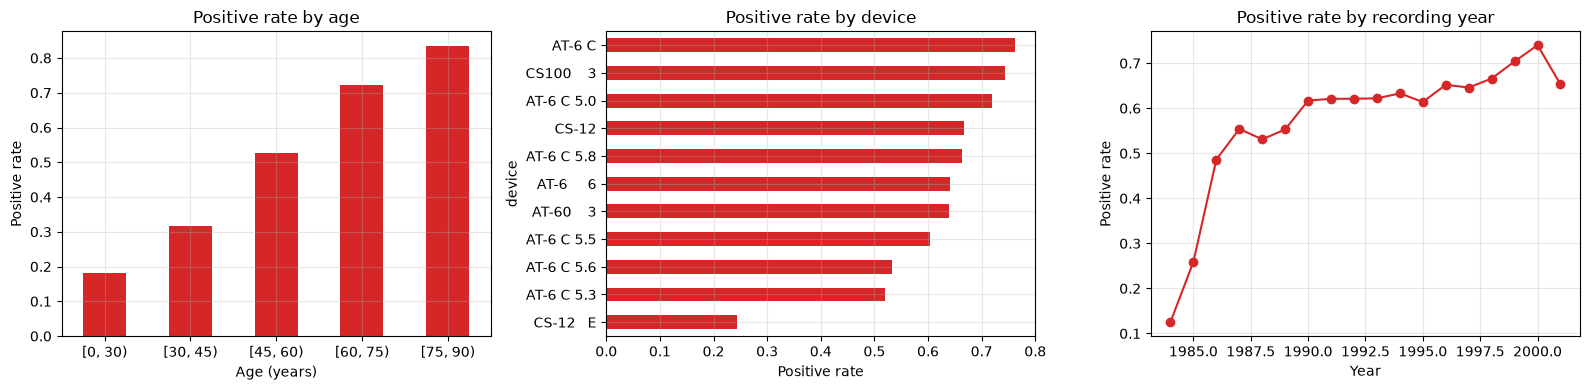

,test,validation
age,0.788,0.794
sex,0.468,0.493
device,0.647,0.654
site,0.651,0.646


In [12]:
rates = positive_rates(meta)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
rates["age_bin"]["positive_rate"].plot.bar(ax=axes[0], color="tab:red", rot=0)
axes[0].set(title="Positive rate by age", xlabel="Age (years)", ylabel="Positive rate")
rates["device"]["positive_rate"].sort_values().plot.barh(ax=axes[1], color="tab:red")
axes[1].set(title="Positive rate by device", xlabel="Positive rate")
rates["year"]["positive_rate"].plot(ax=axes[2], marker="o", color="tab:red")
axes[2].set(title="Positive rate by recording year", xlabel="Year", ylabel="Positive rate")
plt.tight_layout()
plt.show()
display(metadata_baselines(meta))

**Finding: age alone reaches AUROC 0.79, device and site about 0.65.** The positive rate
climbs from 18% under 30 years to 84% over 75. That is clinically expected, but it
means **every model should be compared against an age-only baseline**, and results
should be broken down by age. A model at 0.95 is much better than 0.79, but the relevant
comparison is the gain over age, not over 0.5.

Device is the more worrying shortcut. The positive rate ranges from 24% (`CS-12 E`) to 74%
(`CS100 3`), and section 3 showed that the device mix changes between training and
evaluation folds. If devices leave a fingerprint in the waveform, a model can partly
learn "which device" instead of "which disease". Section 8 checks whether they do.

## 7. Signal integrity

Now the waveforms. For every one of the 21,799 records, `eda/signals.py` computes
per-lead statistics from the raw 500 Hz file (about 90 seconds on 6 cores, then
cached). Integrity checks:

- **shape and NaNs**: every record should be 5000 x 12 with no missing samples;
- **flat leads**: a run of identical samples of at least 1 s, or a fully constant lead;
- **amplitude**: any sample above 10 mV (a normal QRS is 0.5-3 mV);
- **limb-lead identities**: the six limb leads are computed from two electrodes, so
  III = II - I, aVR = -(I + II)/2, aVL = (I - III)/2 and aVF = (II + III)/2 must hold. A
  violation above 0.05 mV means a lead is swapped, mislabeled, clipped or corrupted.

In [13]:
summary = ptbxl_summary(meta)
display(problem_counts(summary).to_frame("records"))
display(summary["samples"].value_counts().to_frame("records by length"))

,records
records,21799
any_nan,0
fully_constant_lead,1
lead_flat_for_1s,2
lead_over_10mv,47
limb_identity_violated,7
heart_rate_not_estimated,0


,records by length
samples,
5000,21799


In [14]:
limb = summary[["einthoven_residual", "avf_residual", "avl_residual", "avr_residual"]].max(axis=1)
problems = summary[(summary["constant_leads"] > 0) | (summary["flat_leads"] > 0) | (limb > 0.05)]
display(problems[["split", "project", "constant_leads", "flat_leads", "peak_abs_mv",
                  "einthoven_residual", "device"]].sort_values("peak_abs_mv", ascending=False))
large = summary[summary["large_leads"] > 0]
display(pd.crosstab(large["split"], large["project"]).rename_axis(index="records with a lead over 10 mV"))

,split,project,constant_leads,flat_leads,peak_abs_mv,einthoven_residual,device
record_id,,,,,,,
10565,train,positive,0,0,32.716,32.753,CS100 3
21171,train,unlabeled,0,0,16.760,0.001,CS100 3
9129,train,unlabeled,0,0,9.937,0.001,CS100 3
15867,validation,unlabeled,0,0,4.240,0.767,AT-6 C
9932,train,positive,0,0,4.229,0.099,AT-6 C
12722,train,positive,1,3,3.611,0.001,AT-6 6
5930,validation,positive,0,0,2.725,0.004,AT-6 C
162,test,positive,0,0,2.585,0.002,AT-6 C
19299,train,positive,0,2,2.152,0.001,CS-12


project,negative,positive,unlabeled
records with a lead over 10 mV,,,
test,1,3,0
train,10,21,9
validation,0,3,0


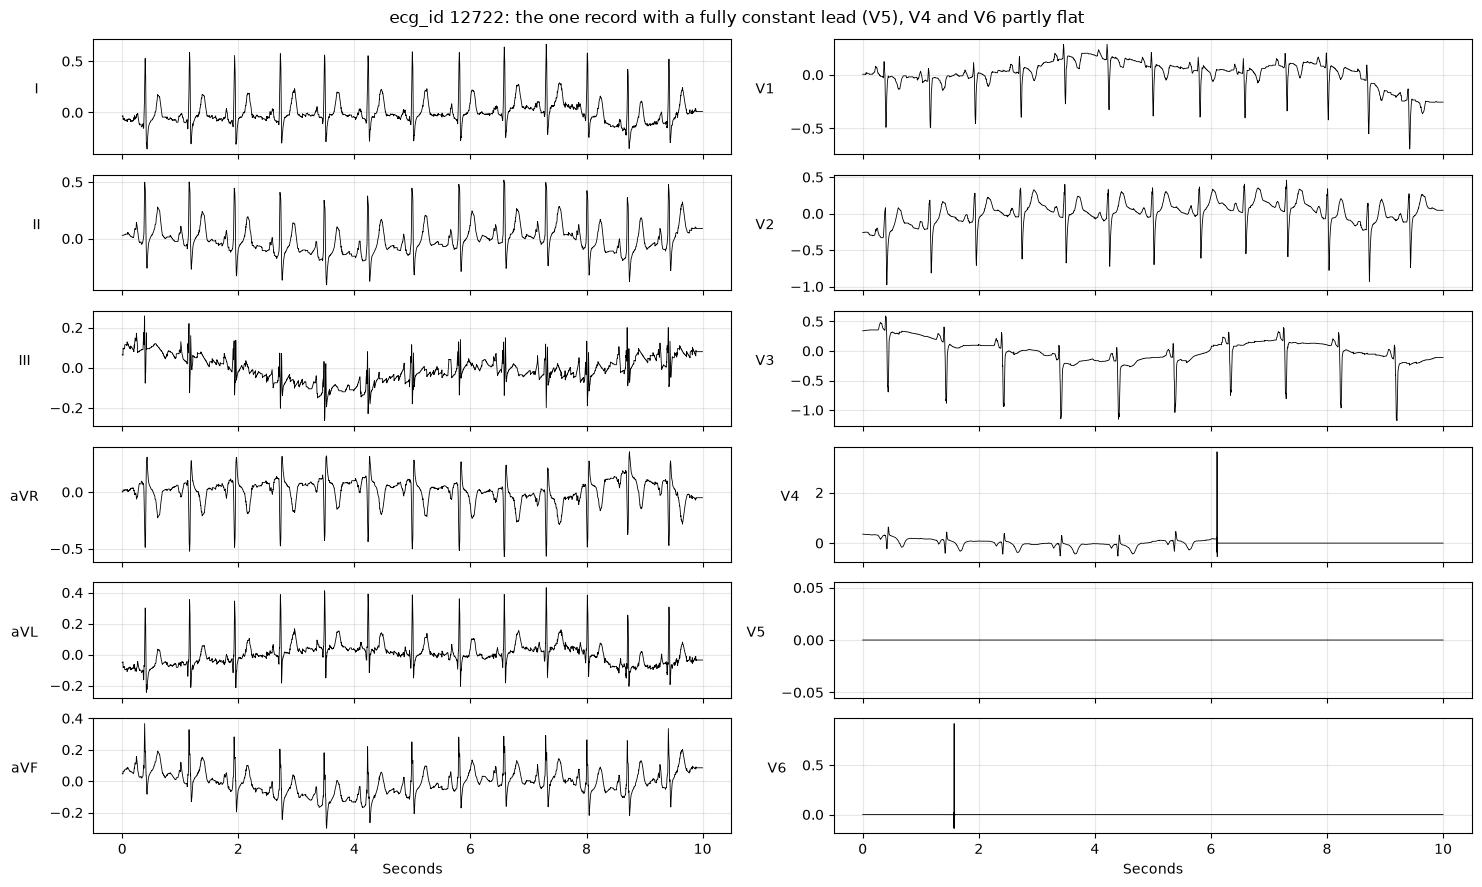

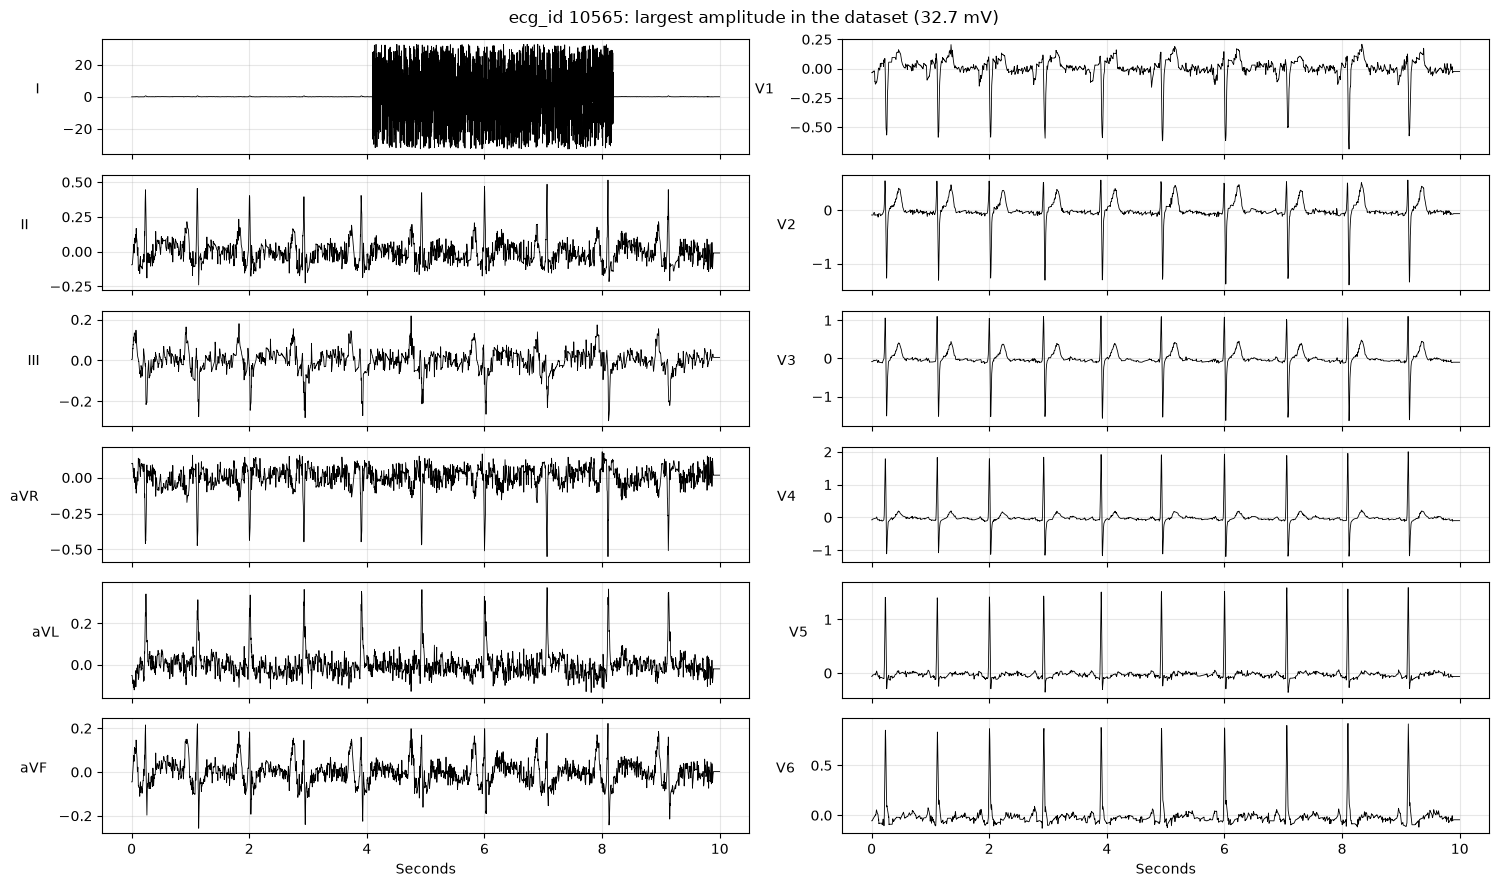

In [15]:
signal, fs = read_signal(meta.loc[12722, "filename_hr"])
plot_ecg(signal, fs, "ecg_id 12722: the one record with a fully constant lead (V5), V4 and V6 partly flat")
plt.show()
spike_id = summary["peak_abs_mv"].idxmax()
signal, fs = read_signal(meta.loc[spike_id, "filename_hr"])
peak = summary.loc[spike_id, "peak_abs_mv"]
plot_ecg(signal, fs, f"ecg_id {spike_id}: largest amplitude in the dataset ({peak:.1f} mV)")
plt.show()

**Finding: the PTB-XL waveforms are very clean.** Every record has exactly 5,000 samples
and no NaNs. The limb-lead identities hold to rounding (0.001 mV) in all but 7 records,
so no leads are swapped anywhere. We found the single fully constant lead the project
already excludes (`ecg_id 12722`, V5), and the plot shows V4 and V6 of that record are
also largely flat. The project's note only mentions V5, but the record is excluded
either way.

47 records have short artifact spikes above 10 mV (up to 33 mV), spread across all
splits and labels. The project clips normalized signals, which limits their effect;
they are not a reason to exclude records.

Next: beyond integrity, what do the signals look like, and do they differ by device or label?

## 8. Signal distributions

Four questions: are the amplitudes plausible per lead; do our noise measures mean
something; do devices differ; and what the label rule did to heart rate.

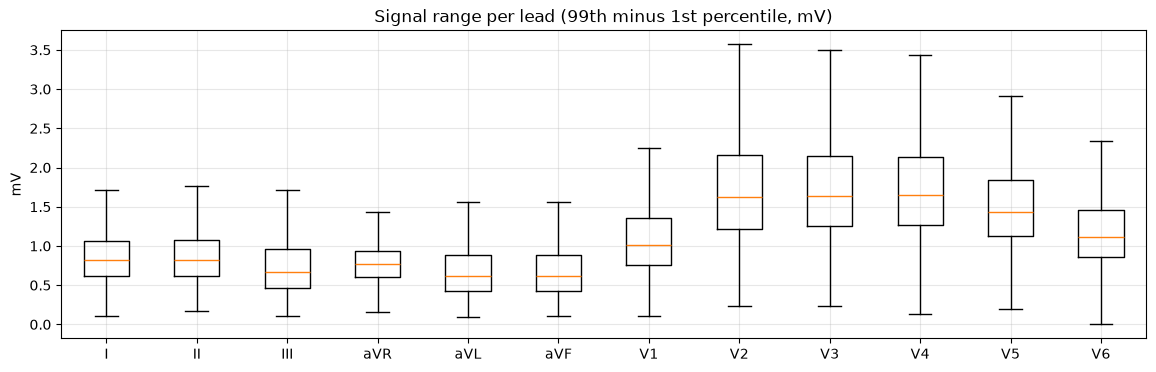

In [16]:
leads = lead_features(meta)
fig, ax = plt.subplots(figsize=(14, 4))
leads["range_mv"] = leads["p99"] - leads["p01"]
per_lead = [leads.loc[leads["lead"] == lead, "range_mv"] for lead in LEADS]
ax.boxplot(per_lead, tick_labels=LEADS, showfliers=False)
ax.set(title="Signal range per lead (99th minus 1st percentile, mV)", ylabel="mV")
plt.show()

In [17]:
display(annotation_agreement(summary))

,annotation,annotated,records,baseline_fraction,high_frequency_fraction,powerline_50_fraction
0,baseline_drift,True,1598,0.065,0.006,7.000e-04
1,baseline_drift,False,20201,0.018,0.007,7.000e-04
2,static_noise,True,3260,0.011,0.009,1.000e-03
3,static_noise,False,18539,0.022,0.006,7.000e-04
4,burst_noise,True,613,0.010,0.007,7.000e-04
5,burst_noise,False,21186,0.020,0.007,7.000e-04
6,electrodes_problems,True,30,0.040,0.007,7.000e-04
7,electrodes_problems,False,21769,0.020,0.007,7.000e-04


**Finding.** Amplitudes follow textbook ECG physiology: the precordial leads V2-V5 have
the largest range (about 1.5 mV) and aVL and aVF the smallest. Units are genuinely mV.

The noise measures are validated by PTB-XL's own human annotations. Records annotated
with baseline drift have 3.6x more power below 0.7 Hz (0.065 vs 0.018), and records
annotated with static noise have more power above 40 Hz. So we can trust these
measures when comparing devices and datasets in the next step.

In [18]:
def labeled_share(labels: pd.Series) -> float:
    """
    Positive rate among records that have a label.

    Parameters
    ----------
    labels : pd.Series
        Project labels of one group.

    Returns
    -------
    float
        Positives divided by positives plus negatives.
    """
    return (labels == "positive").sum() / labels.isin(["positive", "negative"]).sum()


by_device = summary.groupby("device").agg(
    records=("std", "size"), positive_rate_among_labeled=("project", labeled_share),
    baseline_fraction=("baseline_fraction", "median"), high_frequency=("high_frequency_fraction", "median"),
    signal_std=("std", "median"))
display(by_device.round(4).sort_values("baseline_fraction"))

,records,positive_rate_among_labeled,baseline_fraction,high_frequency,signal_std
device,,,,,
AT-60 3,966,0.640,0.003,0.007,0.135
CS100 3,6140,0.744,0.003,0.006,0.146
AT-6 C,514,0.762,0.030,0.006,0.166
CS-12 E,2878,0.244,0.032,0.007,0.156
CS-12,4048,0.668,0.033,0.008,0.144
AT-6 C 5.5,3950,0.603,0.039,0.007,0.162
AT-6 C 5.0,80,0.720,0.041,0.006,0.167
AT-6 6,2273,0.641,0.043,0.007,0.163
AT-6 C 5.3,67,0.518,0.043,0.009,0.163


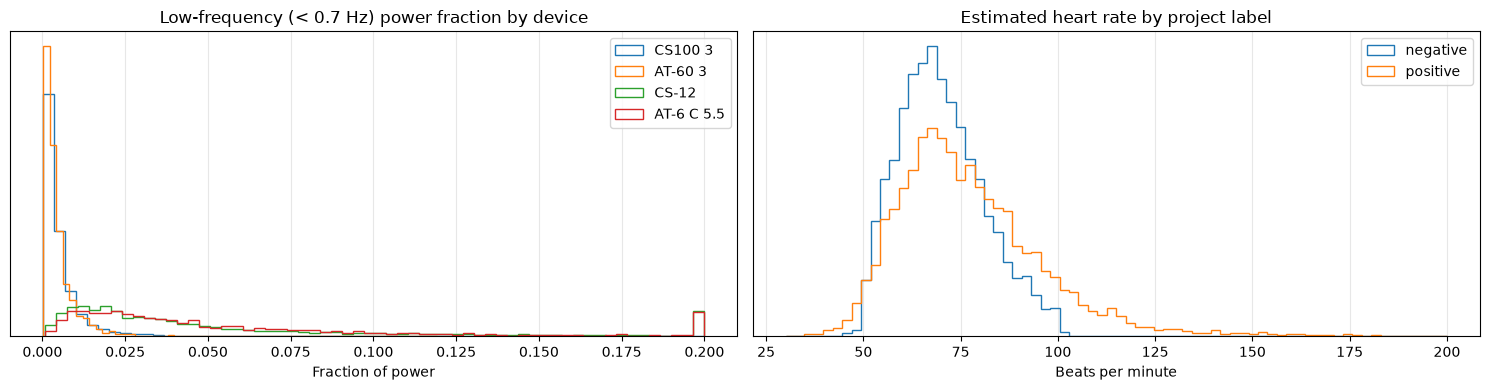

,count,mean,std,min,25%,50%,75%,max
project,,,,,,,,
negative,7252.0,70.1,11.1,43.5,62.0,68.8,77.1,117.4
positive,11874.0,77.4,19.3,27.3,64.2,74.1,86.8,198.7


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for device in ["CS100    3", "AT-60    3", "CS-12", "AT-6 C 5.5"]:
    values = summary.loc[summary["device"] == device, "baseline_fraction"].clip(upper=0.2)
    name = " ".join(device.split())
    axes[0].hist(values, bins=60, histtype="step", density=True, label=name)
axes[0].set(title="Low-frequency (< 0.7 Hz) power fraction by device", xlabel="Fraction of power", yticks=[])
axes[0].legend()
labeled = summary[summary["project"] != "unlabeled"]
for label in ("negative", "positive"):
    axes[1].hist(labeled.loc[labeled["project"] == label, "heart_rate"], bins=70, range=(30, 200),
                 histtype="step", density=True, label=label)
axes[1].set(title="Estimated heart rate by project label", xlabel="Beats per minute", yticks=[])
axes[1].legend()
plt.tight_layout()
plt.show()
display(labeled.groupby("project")["heart_rate"].describe().round(1))

**Finding: devices leave a fingerprint, and the label rule restricts the negatives' heart rate.**

- `CS100 3` and `AT-60 3` have about **10x less low-frequency power** than every other
  device (median fraction 0.003 against 0.03-0.05). They almost certainly apply an
  internal high-pass filter. Combined with section 6, `CS100 3` combines one of the
  highest positive rates (74%), the largest share of training data (35%) and a distinct
  signal fingerprint, and it is nearly absent from the test fold. This combination is
  exactly how a shortcut survives training and then distorts evaluation. It deserves a
  per-device evaluation, or a check that the model's scores do not track device.
- **Every negative has an estimated heart rate between about 43 and 117 bpm**, while
  positives range from 27 to 199. That follows directly from the label rule: a NORM
  record with sinus bradycardia or tachycardia is "unlabeled", not negative. Among
  labeled records, an extreme heart rate alone therefore means "positive". It is a
  real signal, but one created by the label definition, and it will not transfer to a
  cohort where normal-but-tachycardic ECGs are labeled normal.

The heart rate is our own rough estimate (QRS peak detection). The MIMIC notebook
validates the estimator against machine-measured RR intervals.

## 9. Looking at the signals

Statistics can hide problems, so here is one randomly chosen record from each diagnostic
superclass.

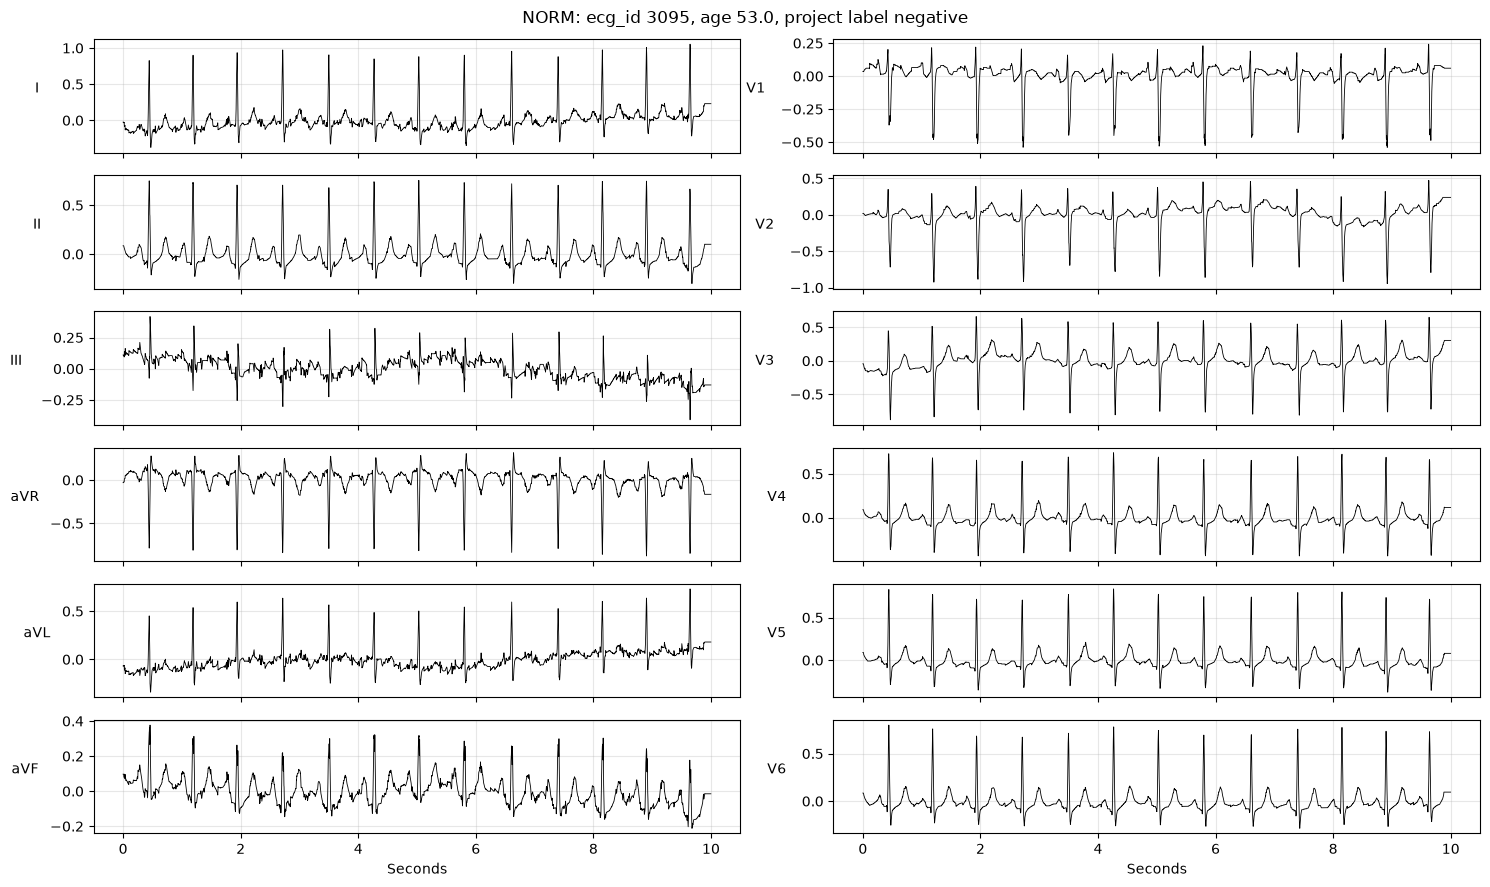

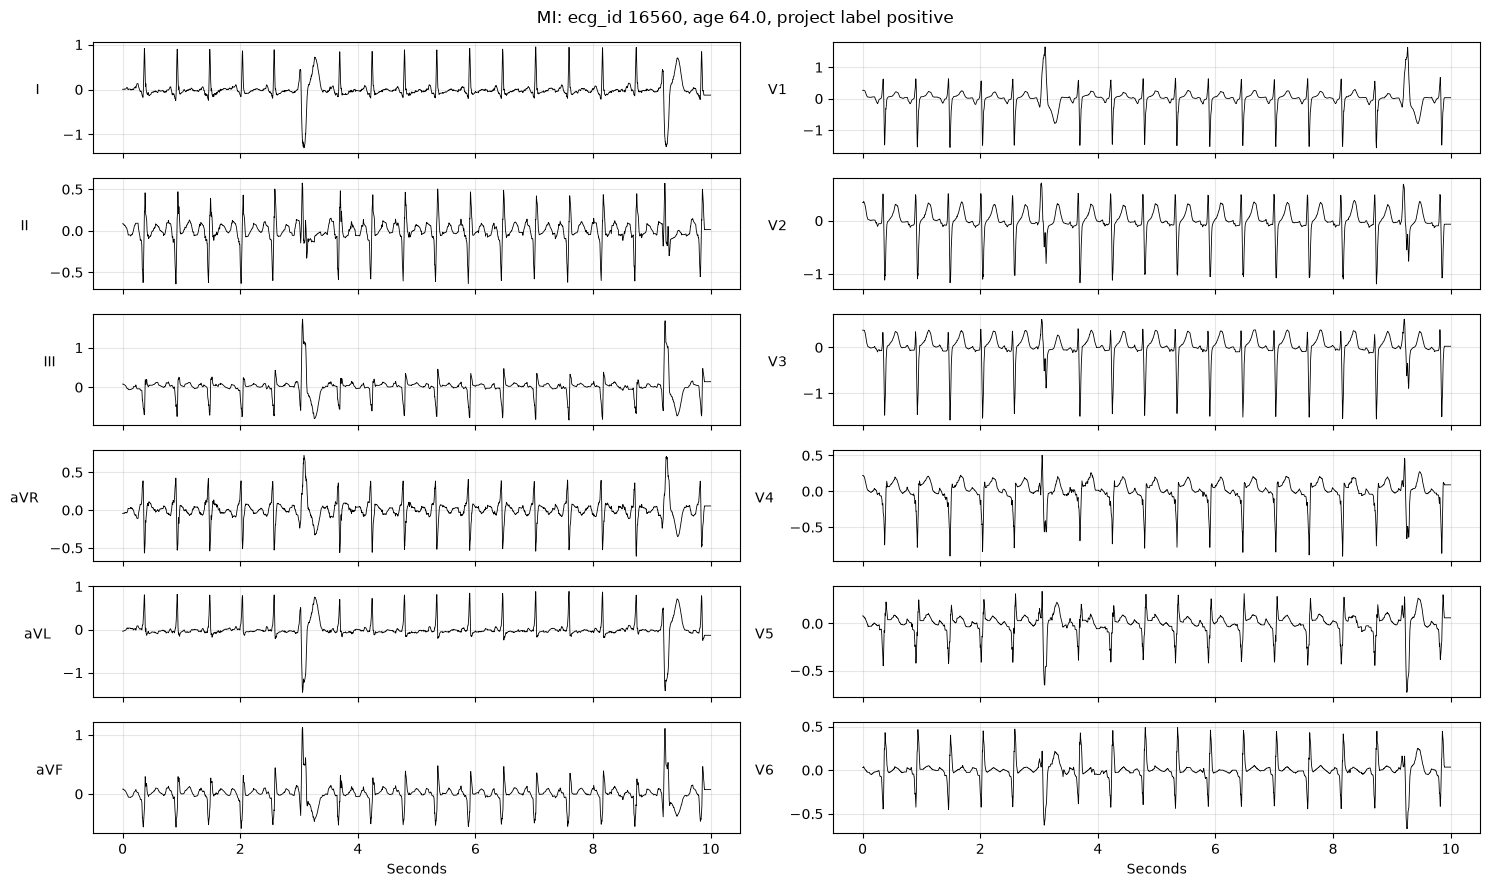

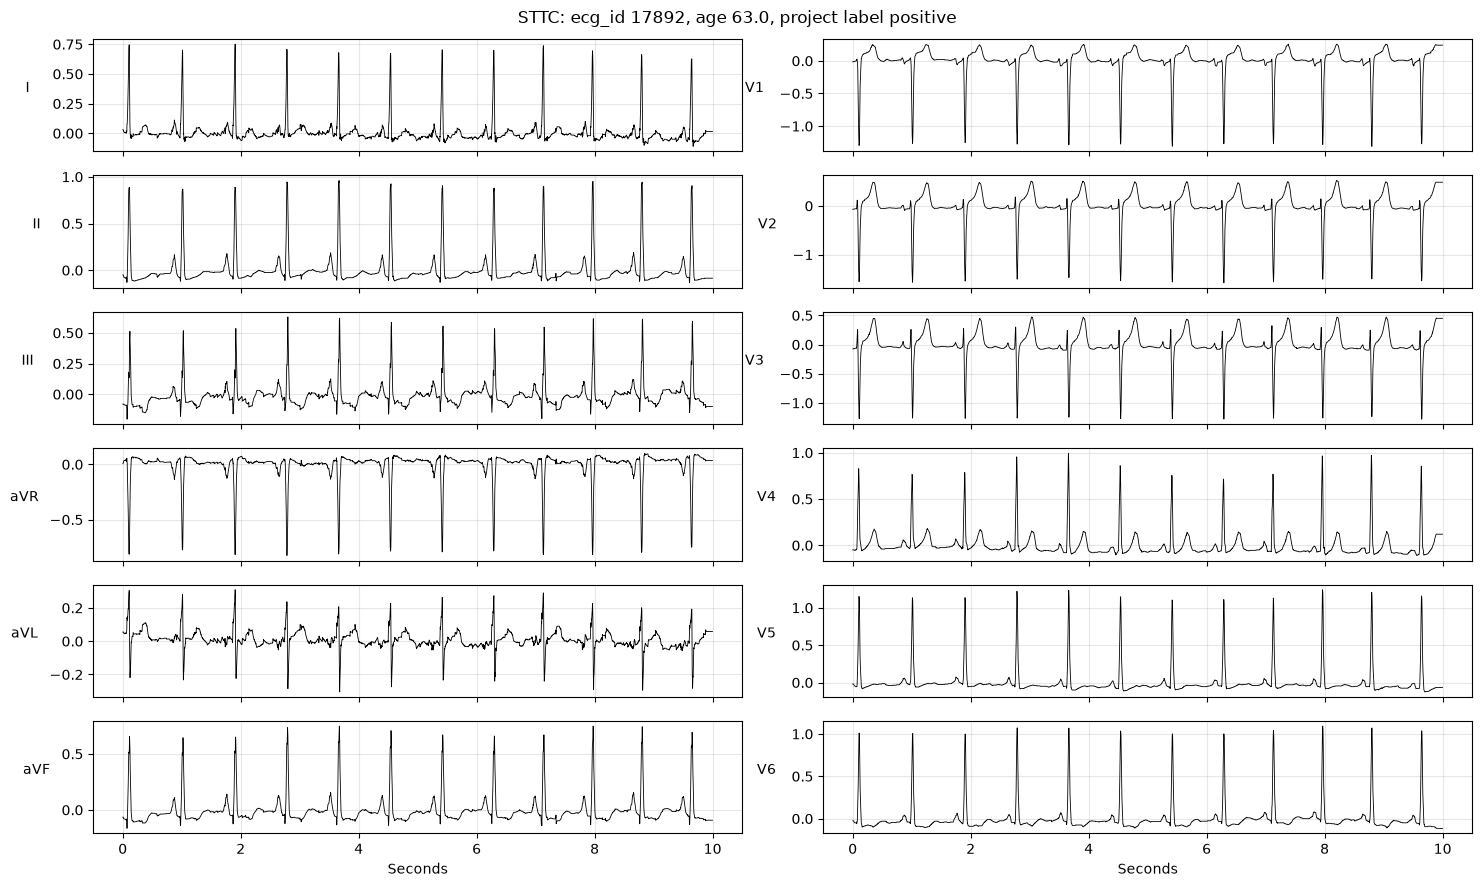

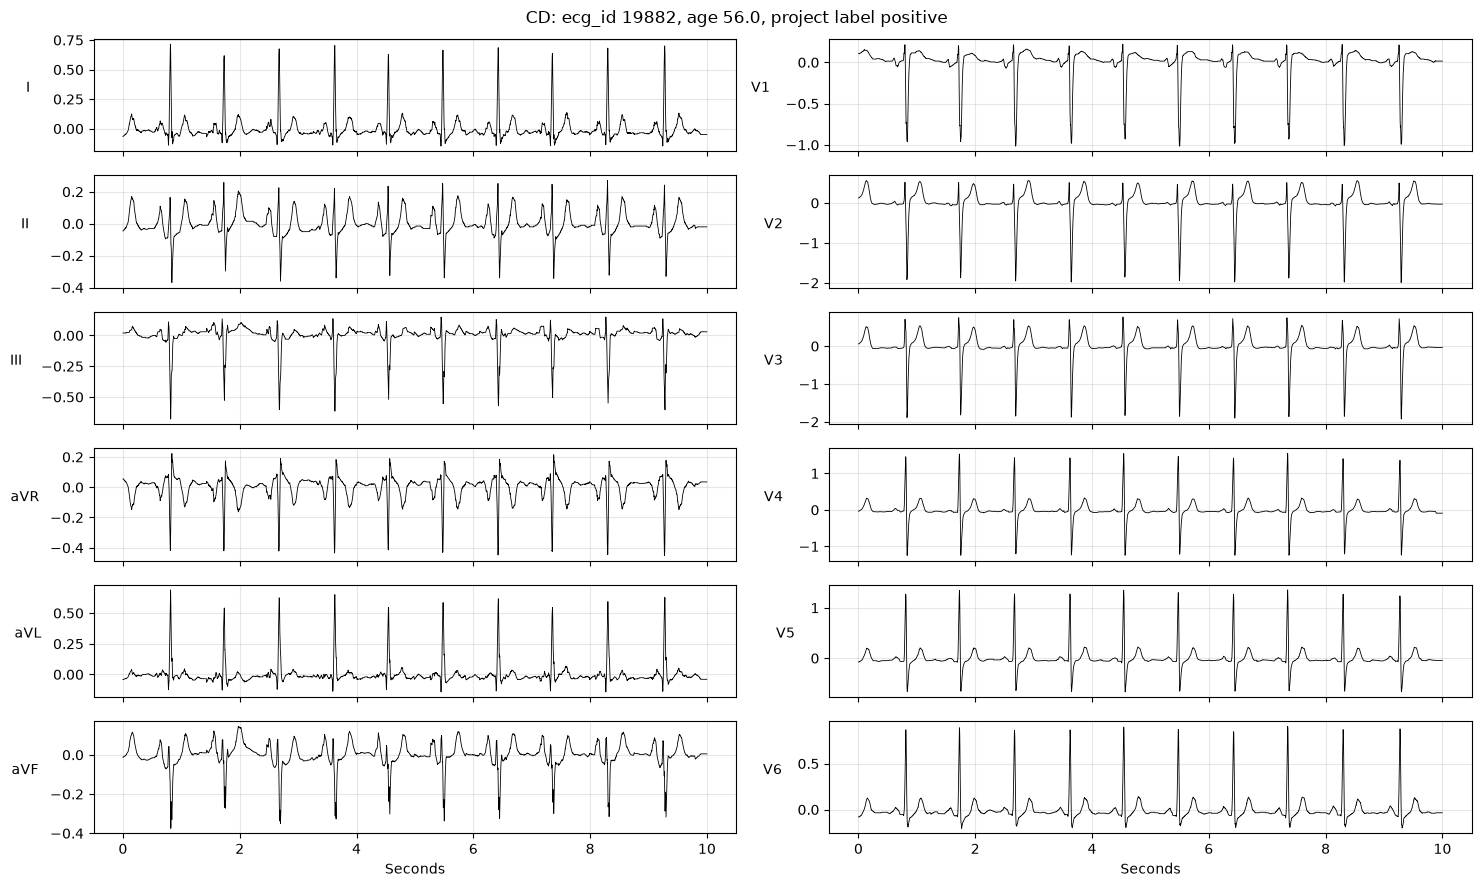

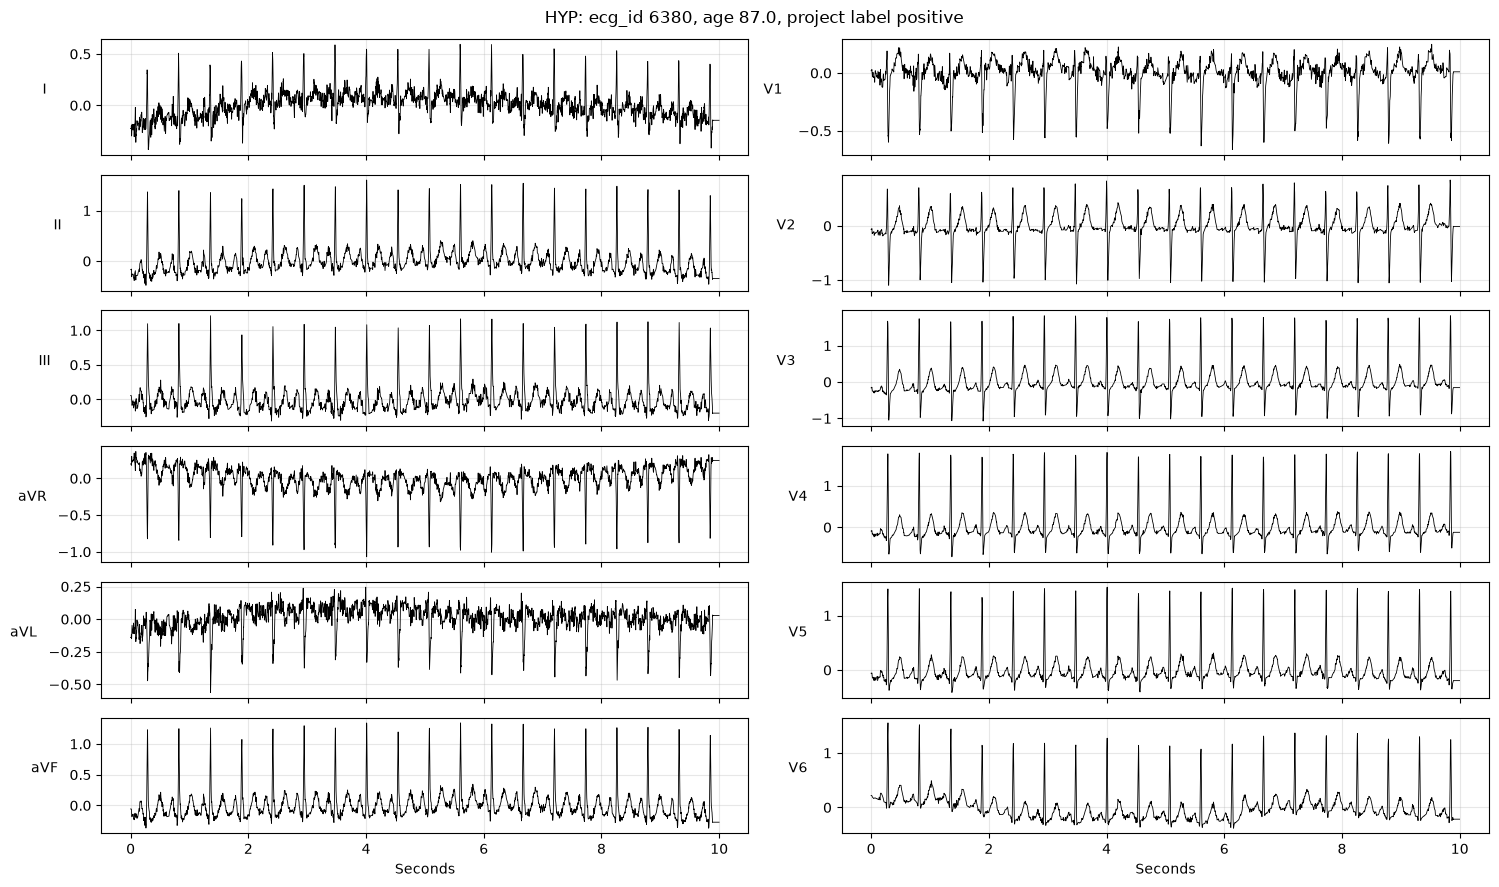

In [20]:
for group in ["NORM", "MI", "STTC", "CD", "HYP"]:
    row = meta[meta["classes"] == group].sample(1, random_state=0).iloc[0]
    signal, fs = read_signal(row["filename_hr"])
    plot_ecg(signal, fs, f"{group}: ecg_id {row.name}, age {row['age']}, project label {row['project']}")
    plt.show()

**Finding.** The records look like standard clinical twelve-lead ECGs. The leads are in
the right place (lead I and V5-V6 upright in normal sinus rhythm, aVR negative), and the
abnormal examples show visible morphology changes. There is nothing structurally odd.

## 10. Raw data versus the project's processed arrays

Clean raw data only helps if the arrays the models actually trained on are faithful
copies of it. The project has three processed forms of PTB-XL:

1. a **100 Hz cache** (`data/processed/ptbxl/waveforms100`), used by the earlier experiments;
2. the **500 Hz union dataset** (`training_union_500hz_v1`);
3. the **250 Hz frozen pool** (`cpc_pool_40k`), used by the CPC experiments. Its receipt
   says each 5-second half was downsampled separately and then concatenated.

We sample records from each and compare them with the raw files. We also check that
PTB-XL's own 100 Hz files agree with its 500 Hz files.

In [21]:
cache = compare_cache_100(records=200)
union = compare_union(per_source=40)
display(pd.DataFrame({
    "100 Hz cache vs raw 100 Hz": cache["max_abs_difference_mv"].describe(),
    "500 Hz union vs raw (PTB-XL rows)":
        union.loc[union["source"] == "ptbxl", "max_abs_difference_mv"].describe(),
}).T[["count", "mean", "max"]])

,count,mean,max
100 Hz cache vs raw 100 Hz,200.0,8.000e-08,2.365e-07
500 Hz union vs raw (PTB-XL rows),40.0,9.906e-08,4.425e-07


In [22]:
consistency = low_rate_consistency(meta, records=300)
display(consistency.describe().round(4))

,correlation,max_abs_difference_mv,median_abs_difference_mv
count,300.000,300.000,3.000e+02
mean,0.990,0.661,2.000e-03
std,0.013,0.612,1.100e-03
min,0.892,0.105,8.000e-04
25%,0.991,0.257,1.300e-03
50%,0.994,0.400,1.700e-03
75%,0.996,0.868,2.400e-03
max,1.000,3.574,5.800e-03


source                         mimic   ptbxl
stored_vs_described_mv count  50.000  30.000
                       mean    0.000   0.000
                       std     0.000   0.000
                       min     0.000   0.000
                       25%     0.000   0.000
                       50%     0.000   0.000
                       75%     0.000   0.000
                       max     0.000   0.000
join_artifact_mv       count  50.000  30.000
                       mean    0.045   0.070
                       std     0.047   0.068
                       min     0.003   0.009
                       25%     0.020   0.028
                       50%     0.035   0.041
                       75%     0.050   0.068
                       max     0.298   0.265
interior_difference_mv count  50.000  30.000
                       mean    0.000   0.000
                       std     0.000   0.000
                       min     0.000   0.000
                       25%     0.000   0.000
                       50%     0.000   0.000
                       75%     0.000   0.000
                       max     0.000   0.000

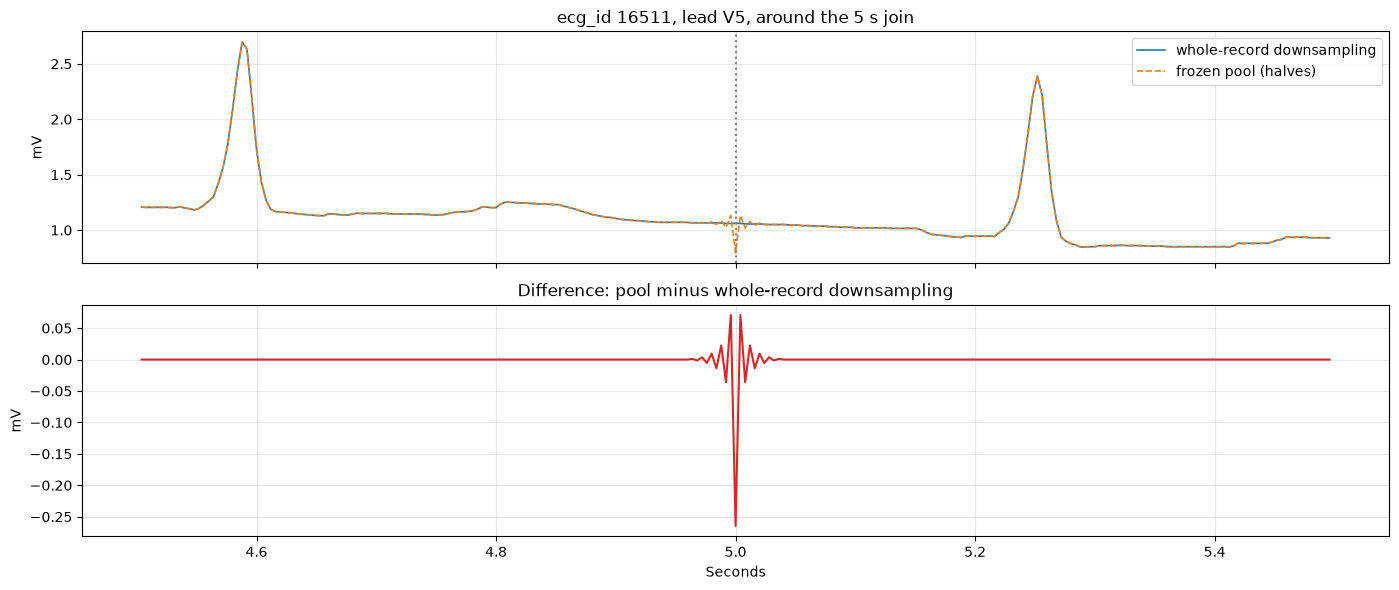

In [23]:
pool = compare_pool(records=80)
display(pool.groupby("source")[["stored_vs_described_mv", "join_artifact_mv", "interior_difference_mv"]]
        .describe().T.round(4))
worst = int(pool[pool["source"] == "ptbxl"].sort_values("join_artifact_mv")["ecg_id"].iloc[-1])
stored, whole, halves = join_example(worst)
lead = int(np.abs(stored - whole).max(axis=1).argmax())
time = np.arange(2500) / 250
window = (time > 4.5) & (time < 5.5)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(time[window], whole[lead, window], label="whole-record downsampling", linewidth=1.2)
axes[0].plot(time[window], stored[lead, window], label="frozen pool (halves)", linewidth=1.2, linestyle="--")
axes[0].axvline(5, color="gray", linestyle=":")
axes[0].set(title=f"ecg_id {worst}, lead {LEADS[lead]}, around the 5 s join", ylabel="mV")
axes[0].legend()
axes[1].plot(time[window], stored[lead, window] - whole[lead, window], color="tab:red")
axes[1].set(title="Difference: pool minus whole-record downsampling", xlabel="Seconds", ylabel="mV")
plt.tight_layout()
plt.show()

**Finding.**

- The **100 Hz cache** and the **500 Hz union** match the raw files to float32 rounding
  (about 1e-7 mV). Lead order, units and record identity are all correct.
- PTB-XL's own **100 Hz files are a smoothed version** of the 500 Hz files: the typical
  sample differs by only about 0.002 mV (correlation 0.99), but the sharpest point of each
  record, usually a QRS peak, differs by a median of 0.4 mV (up to 3.6 mV at artifact spikes)
  because a different anti-aliasing filter was used. Models trained at 100 Hz see
  slightly blunted QRS complexes. That is a known limitation of the 100 Hz release, not
  an error.
- The **250 Hz frozen pool** is exactly what its receipt describes, but the method itself
  is flawed. Downsampling the two halves separately creates a filter-edge artifact at the
  5-second join. Its median is about 0.04 mV and it reaches about 0.3 mV, comparable to
  a P wave, and it sits at the same position in every record. Everywhere else the pool is
  identical to downsampling the whole record. A self-supervised model can learn a feature
  that appears at a fixed time in 60,000 records. Re-creating the pool with whole-record
  resampling removes it at no cost.

## 11. Conclusions

**What is correct**

- The raw PTB-XL data are complete and clean: no NaNs, consistent lengths, correct
  lead identities, plausible physiology.
- The project's label rule is implemented exactly as documented, the official folds are
  used correctly, patient splits never leak, and the limited-label subset is nested and
  patient-complete.
- The 100 Hz cache and the 500 Hz union are faithful copies of the raw files.

**What needs attention** (most important first)

1. **Evaluation excludes the hard cases.** 14% of validation and test (borderline
   normals, conflicting annotations, rhythm-only abnormalities) is removed, so reported
   AUROCs are optimistic and not comparable to PTB-XL benchmarks. *Recommendation:* also
   report on all of folds 9 and 10 with the standard superclass label, and state which
   labeling the headline numbers use.
2. **Strong metadata baselines are missing.** Age alone gives AUROC 0.79. *Recommendation:*
   report an age-only (and age + sex) baseline next to every model, and stratify results
   by age.
3. **Device is a plausible shortcut.** Devices differ in label rate (24-74%) and in signal
   filtering, and the device mix shifts between training and evaluation folds.
   *Recommendation:* report per-device performance, and check whether the model's scores
   predict device.
4. **The label rule restricts the negatives' heart rate** to 43-117 bpm, which will not hold
   in the university cohort.
5. **The 250 Hz frozen pool has a join artifact at 5 s.** *Recommendation:* rebuild it with
   whole-record resampling before new experiments.

The next notebooks apply the same checks to the unlabeled sources used for
self-supervised pretraining, starting with MIMIC-IV-ECG, the largest one.